In [1]:
!pip install pyspark

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, to_date, count, sum, when, approx_count_distinct, expr, avg, stddev
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Thiết lập style biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
spark = SparkSession.builder \
    .appName("User Persona Clustering & Viz") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Đọc dữ liệu với tùy chọn xử lý dấu ngoặc kép chứa dấu phẩy
data_path = "/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv"
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .csv(data_path)

print("=== THÔNG TIN DỮ LIỆU ===")
print(f"Tổng số records: {df.count()}")
print(f"Số lượng user: {df.select('user_id').distinct().count()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 10:39:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/16 10:39:40 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv.
java.io.FileNotFoundException: File /kaggle/input/datasets/js042710/second3t1k/CLEARDATA/CLEARDATA/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFi

=== THÔNG TIN DỮ LIỆU ===


Tổng số records: 80632131


Số lượng user: 23800


In [4]:
# Dùng try_cast: Nếu giá trị không phải thời gian (như tên phim), nó sẽ biến thành NULL
df_clean = df.withColumn("ts", expr("try_cast(timestamp as timestamp)"))

# Xóa bỏ hoàn toàn những dòng bị biến thành NULL ở bước trên
df_clean = df_clean.dropna(subset=["ts"])

# Tạo thêm các cột giờ và ngày từ dữ liệu đã sạch
df_clean = df_clean.withColumn("hour", hour(col("ts"))) \
                   .withColumn("date", to_date(col("ts")))

print(f"\nSố records sau khi làm sạch: {df_clean.count()}")


Số records sau khi làm sạch: 80631061


In [5]:
user_features = df_clean.groupBy("user_id").agg(
    count("*").alias("total_listens"),
    approx_count_distinct("track_name").alias("unique_tracks"),
    approx_count_distinct("artist_name").alias("unique_artists"),
    approx_count_distinct("date").alias("active_days"),
    sum(when((col("hour") >= 22) | (col("hour") <= 4), 1).otherwise(0)).alias("night_listens")
).withColumn("night_ratio", col("night_listens") / col("total_listens")).fillna(0)

# Thêm feature về tính đa dạng
user_features = user_features.withColumn(
    "diversity_score", 
    (col("unique_tracks") / col("total_listens")) * 100
).fillna(0)

print("\n=== ĐẶC TRƯNG USER ===")
user_features.show(10)

# Thống kê cơ bản
print("\n=== THỐNG KÊ CƠ BẢN ===")
user_features.describe().show()


=== ĐẶC TRƯNG USER ===


26/03/16 10:43:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------+-------------+--------------+-----------+-------------+--------------------+------------------+
|user_id|total_listens|unique_tracks|unique_artists|active_days|night_listens|         night_ratio|   diversity_score|
+-------+-------------+-------------+--------------+-----------+-------------+--------------------+------------------+
|    296|           36|           34|             8|          6|           34|  0.9444444444444444| 94.44444444444444|
|    675|          623|          559|           466|         25|           24|0.038523274478330656|  89.7271268057785|
|    829|          412|          414|           225|         27|          157| 0.38106796116504854|100.48543689320388|
|  14204|          983|          384|           316|         30|          287| 0.29196337741607326| 39.06408952187182|
|  14899|         2777|         2078|           679|         30|         1413|  0.5088224702916817| 74.82895210658984|
|  16576|          264|          135|           

+-------+------------------+------------------+-----------------+------------------+-----------------+-----------------+-------------------+-------------------+
|summary|           user_id|     total_listens|    unique_tracks|    unique_artists|      active_days|    night_listens|        night_ratio|    diversity_score|
+-------+------------------+------------------+-----------------+------------------+-----------------+-----------------+-------------------+-------------------+
|  count|             23376|             23376|            23376|             23376|            23376|            23376|              23376|              23376|
|   mean| 53396.70354209446|3449.3095910335387|934.1249572210814| 336.2395191649555|81.57486310746064|822.1554585900069|  0.237062368048458|  70.82167735184956|
| stddev|26702.891507605993|24180.107031094514| 4274.17235014179|1414.6573161044312|420.4536801535149|6822.900925707009|0.24488468054458928|  24.25648553006339|
|    min|                 1|      

In [6]:
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler

print("\n=== TÌM K TỐI ƯU CHO K-MEANS (ĐÃ TỐI ƯU TỐC ĐỘ) ===")

# Chuẩn bị features
feature_cols = ["total_listens", "active_days", "night_ratio", "diversity_score"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled_data = assembler.transform(user_features)

# Chuẩn hóa dữ liệu
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

# --- TỐI ƯU 1: CACHE DỮ LIỆU VÀO RAM ---
# Lệnh này ép Spark tính toán bộ dữ liệu đã scale MỘT LẦN DUY NHẤT và giữ trong RAM
scaled_data.cache()

# --- TỐI ƯU 2: SAMPLING (LẤY MẪU) ---
# Để tìm ra hình dáng đồ thị Elbow và Silhouette, ta không cần dùng 100% dữ liệu.
# Lấy mẫu 10% - 20% dữ liệu ngẫu nhiên là đủ để tìm K chính xác mà tốc độ tăng phi mã.
# Chú ý: Thay đổi fraction=0.1 tùy theo độ lớn của data (nếu data quá lớn có thể dùng 0.05)
sampled_data = scaled_data.sample(fraction=0.1, seed=42)
sampled_data.cache() # Cache luôn cả tập mẫu này

# Thử nghiệm với các giá trị K khác nhau
k_values = range(2, 7)
silhouette_scores = []
wssse_scores = []

# Đưa tập dữ liệu MẪU vào vòng lặp thay vì toàn bộ dữ liệu
for k in k_values:
    # TỐI ƯU 3: nới lỏng tol (sai số hội tụ) một chút để mô hình chốt K nhanh hơn
    kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=k, seed=42, maxIter=10, tol=1e-3)
    
    # Huấn luyện trên tập MẪU
    model = kmeans.fit(sampled_data)
    predictions = model.transform(sampled_data)
    
    # Tính Silhouette Score 
    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    # Tính WSSSE
    wssse = model.summary.trainingCost
    wssse_scores.append(wssse)
    
    print(f"K = {k}: Silhouette = {silhouette:.4f}, WSSSE = {wssse:.2f}")

# Dọn dẹp RAM sau khi dùng xong tập mẫu
sampled_data.unpersist()

# QUAN TRỌNG: 
# Sau khi nhìn kết quả in ra và chọn được K ưng ý (ví dụ K=3), 
# hãy ra ngoài vòng lặp này và chạy fit model một lần cuối bằng TOÀN BỘ dữ liệu `scaled_data`.


=== TÌM K TỐI ƯU CHO K-MEANS (ĐÃ TỐI ƯU TỐC ĐỘ) ===


K = 2: Silhouette = 0.3557, WSSSE = 5610.09


K = 3: Silhouette = 0.4562, WSSSE = 4052.55


K = 4: Silhouette = 0.6016, WSSSE = 2156.39


K = 5: Silhouette = 0.5726, WSSSE = 1838.69


K = 6: Silhouette = 0.5788, WSSSE = 1589.95


DataFrame[user_id: string, total_listens: bigint, unique_tracks: bigint, unique_artists: bigint, active_days: bigint, night_listens: bigint, night_ratio: double, diversity_score: double, raw_features: vector, features: vector]

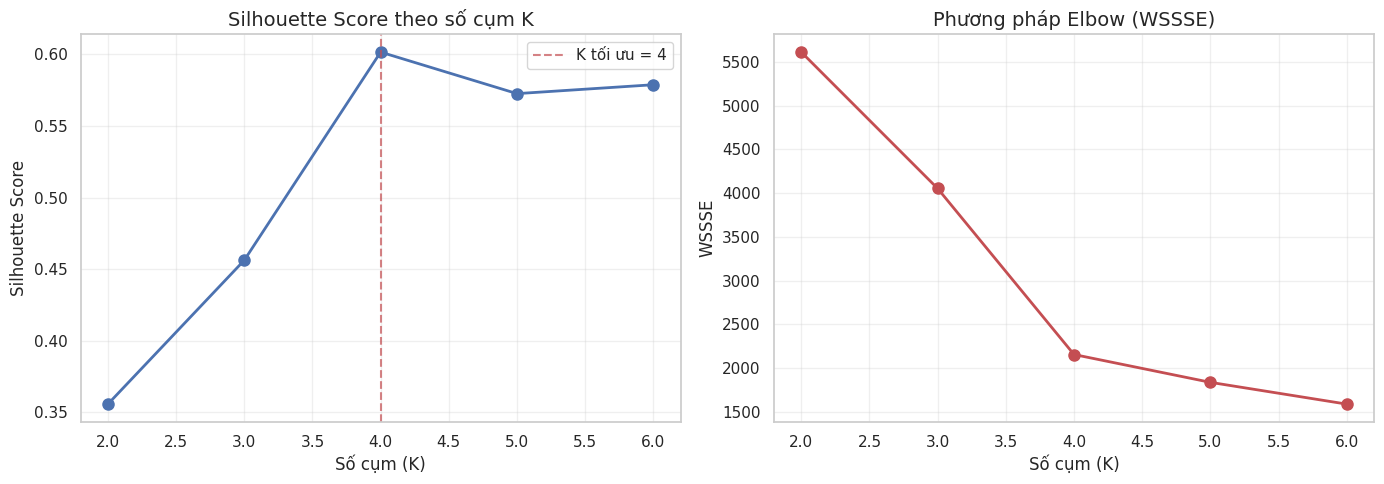

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Silhouette Score
axes[0].plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Số cụm (K)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score theo số cụm K', fontsize=14)
axes[0].grid(True, alpha=0.3)
# Đánh dấu K tối ưu
optimal_k_sil = k_values[np.argmax(silhouette_scores)]
axes[0].axvline(x=optimal_k_sil, color='r', linestyle='--', alpha=0.7, label=f'K tối ưu = {optimal_k_sil}')
axes[0].legend()

# Biểu đồ WSSSE (Elbow Method)
axes[1].plot(k_values, wssse_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Số cụm (K)', fontsize=12)
axes[1].set_ylabel('WSSSE', fontsize=12)
axes[1].set_title('Phương pháp Elbow (WSSSE)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
optimal_k = 3  # Có thể điều chỉnh dựa trên biểu đồ trên

print(f"\n=== CHẠY K-MEANS VỚI K = {optimal_k} ===")

kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=optimal_k, seed=42, maxIter=20)
model = kmeans.fit(scaled_data)
predictions = model.transform(scaled_data)

# Đánh giá cuối cùng
final_evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")
final_silhouette = final_evaluator.evaluate(predictions)
print(f"Silhouette Score cuối cùng: {final_silhouette:.4f}")


=== CHẠY K-MEANS VỚI K = 3 ===


Silhouette Score cuối cùng: 0.4721


In [9]:
# Phân tích đặc điểm từng cluster
cluster_analysis = predictions.groupBy("cluster").agg(
    count("user_id").alias("user_count"),
    avg("total_listens").alias("avg_total_listens"),
    avg("night_ratio").alias("avg_night_ratio"),
    avg("diversity_score").alias("avg_diversity"),
    avg("active_days").alias("avg_active_days")
).orderBy("cluster")

cluster_profile = cluster_analysis.toPandas()
print("\n=== ĐẶC ĐIỂM CÁC CỤM ===")
print(cluster_profile)

# Gán nhãn dựa trên đặc điểm
def assign_labels(row):
    if row['avg_night_ratio'] > 0.3:  # Nghe đêm > 30%
        return "Cú đêm"
    elif row['avg_total_listens'] > cluster_profile['avg_total_listens'].mean():  # Trên trung bình
        return "Fan cứng"
    else:
        return "Người mới"

cluster_profile['user_type'] = cluster_profile.apply(assign_labels, axis=1)
label_mapping = dict(zip(cluster_profile['cluster'], cluster_profile['user_type']))
print("\n=== GÁN NHÃN CHO CÁC CỤM ===")
print(label_mapping)

# Thêm nhãn vào kết quả
from pyspark.sql.functions import create_map, lit
mapping_expr = create_map([lit(x) for pair in label_mapping.items() for x in pair])
final_results = predictions.withColumn("user_type", mapping_expr.getItem(col("cluster")))


=== ĐẶC ĐIỂM CÁC CỤM ===
   cluster  user_count  avg_total_listens  avg_night_ratio  avg_diversity  \
0        0       10064        1945.015004         0.438718      60.317083   
1        1         398      137029.678392         0.233210      21.636876   
2        2       12914         504.771411         0.080029      80.523845   

   avg_active_days  
0        51.515600  
1      2946.195980  
2        16.714806  

=== GÁN NHÃN CHO CÁC CỤM ===
{0: 'Cú đêm', 1: 'Fan cứng', 2: 'Người mới'}


/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


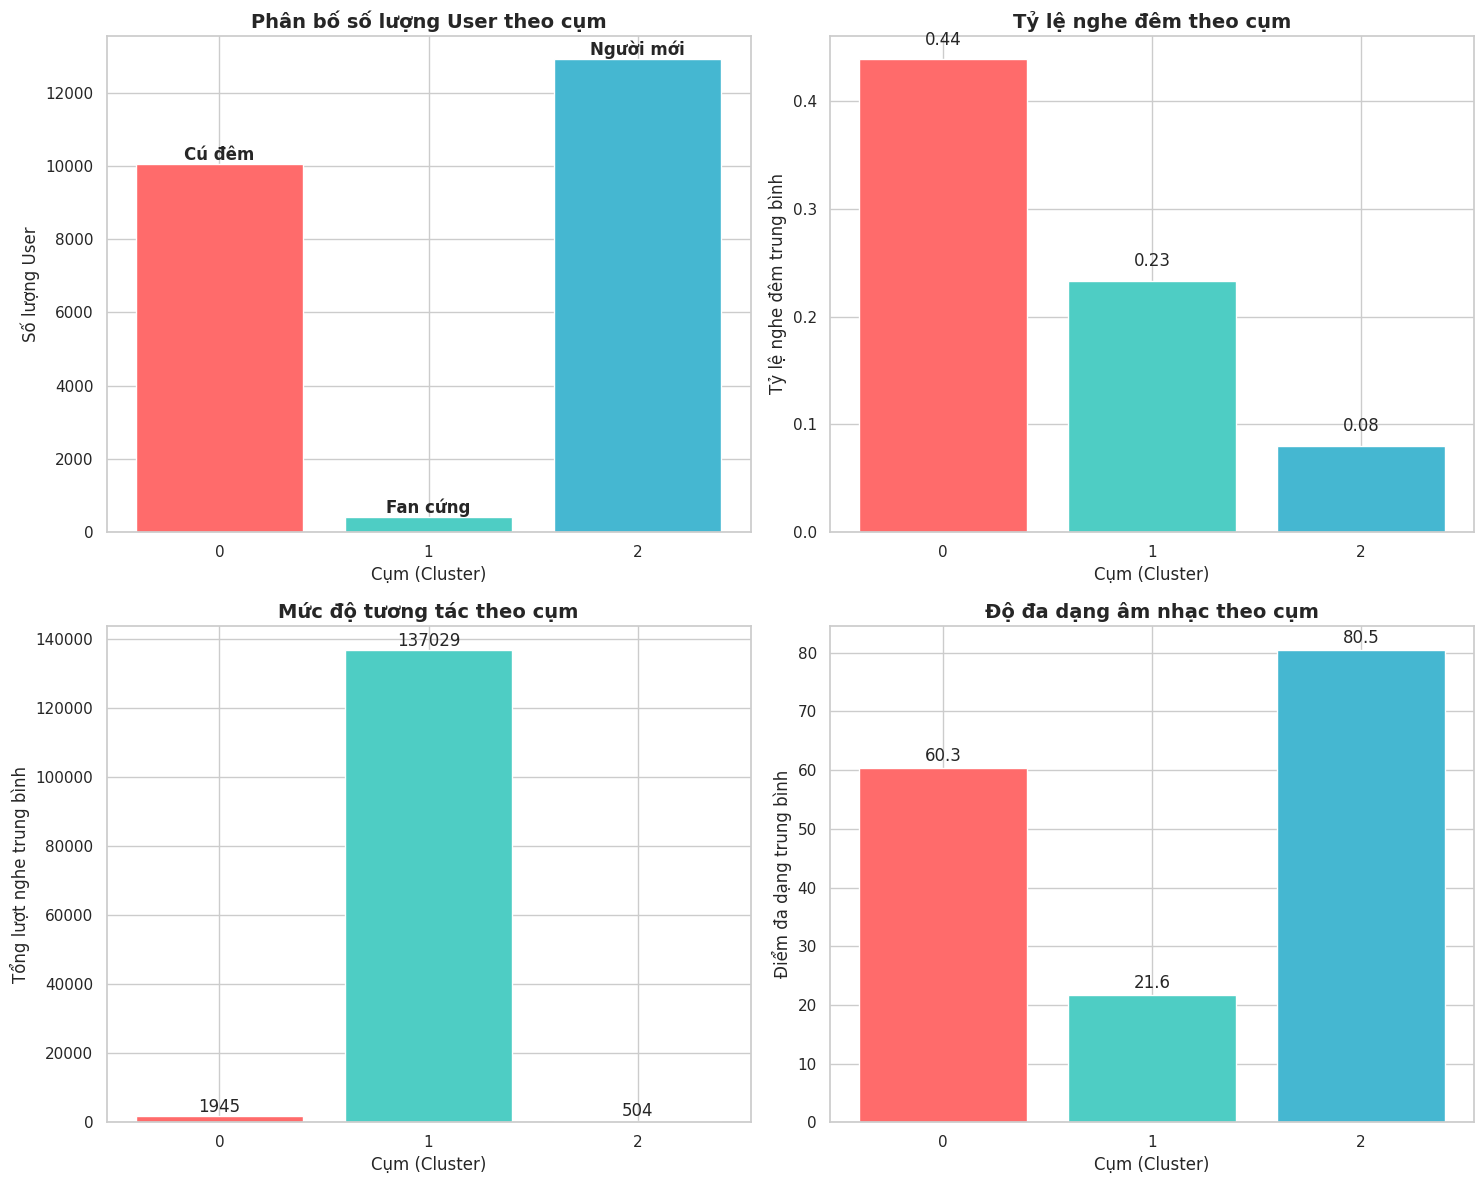

In [10]:
# --- Biểu đồ 1: Đặc điểm các cụm ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Số lượng user mỗi cluster
ax1 = axes[0, 0]
bars1 = ax1.bar(cluster_profile['cluster'].astype(str), cluster_profile['user_count'], 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_xlabel('Cụm (Cluster)', fontsize=12)
ax1.set_ylabel('Số lượng User', fontsize=12)
ax1.set_title('Phân bố số lượng User theo cụm', fontsize=14, fontweight='bold')
# Thêm nhãn
for bar, label in zip(bars1, cluster_profile['user_type']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             label, ha='center', va='bottom', fontweight='bold')

# Tỷ lệ nghe đêm trung bình
ax2 = axes[0, 1]
bars2 = ax2.bar(cluster_profile['cluster'].astype(str), cluster_profile['avg_night_ratio'], 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_xlabel('Cụm (Cluster)', fontsize=12)
ax2.set_ylabel('Tỷ lệ nghe đêm trung bình', fontsize=12)
ax2.set_title('Tỷ lệ nghe đêm theo cụm', fontsize=14, fontweight='bold')
for bar, label in zip(bars2, cluster_profile['user_type']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{bar.get_height():.2f}', ha='center', va='bottom')

# Tổng lượt nghe trung bình
ax3 = axes[1, 0]
bars3 = ax3.bar(cluster_profile['cluster'].astype(str), cluster_profile['avg_total_listens'], 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_xlabel('Cụm (Cluster)', fontsize=12)
ax3.set_ylabel('Tổng lượt nghe trung bình', fontsize=12)
ax3.set_title('Mức độ tương tác theo cụm', fontsize=14, fontweight='bold')
for bar, label in zip(bars3, cluster_profile['user_type']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{int(bar.get_height())}', ha='center', va='bottom')

# Điểm đa dạng trung bình
ax4 = axes[1, 1]
bars4 = ax4.bar(cluster_profile['cluster'].astype(str), cluster_profile['avg_diversity'], 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax4.set_xlabel('Cụm (Cluster)', fontsize=12)
ax4.set_ylabel('Điểm đa dạng trung bình', fontsize=12)
ax4.set_title('Độ đa dạng âm nhạc theo cụm', fontsize=14, fontweight='bold')
for bar, label in zip(bars4, cluster_profile['user_type']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{bar.get_height():.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

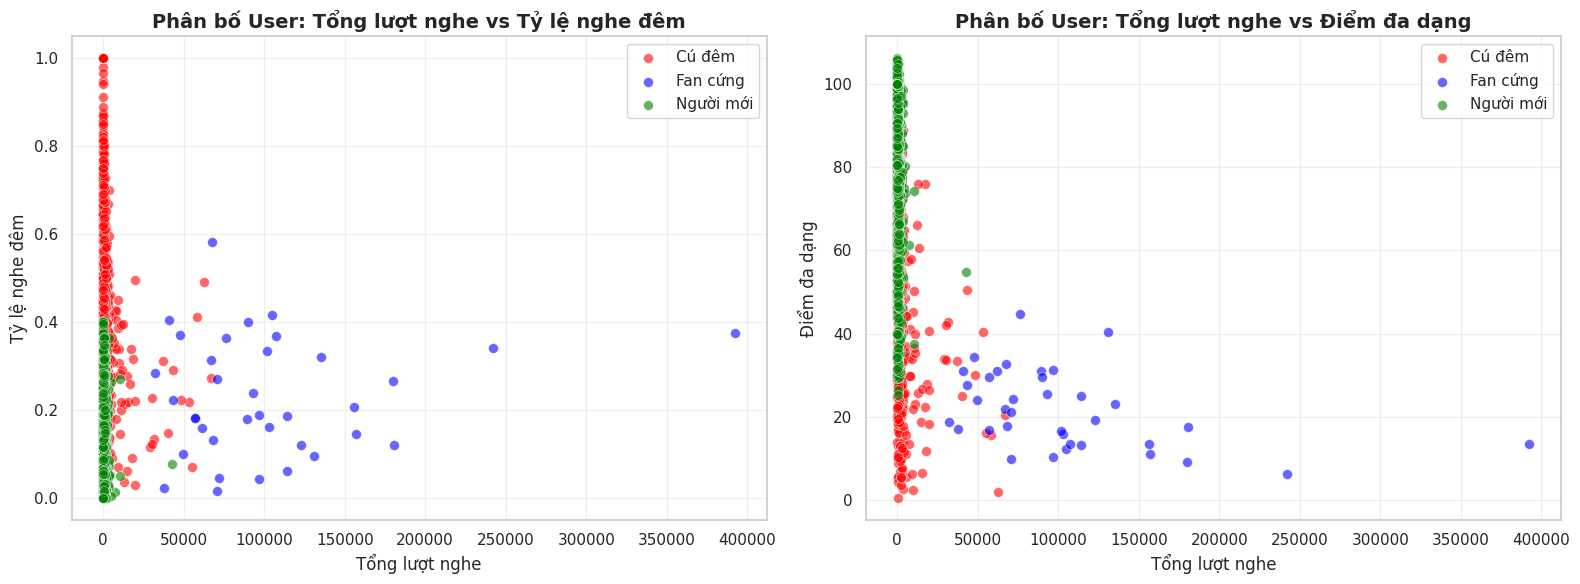

In [11]:
# --- Biểu đồ 2: Scatter Plot 2D với màu sắc theo cluster ---
# Lấy mẫu 10% dữ liệu để vẽ
sample_data = final_results.select("total_listens", "night_ratio", "diversity_score", "cluster", "user_type") \
                           .sample(fraction=0.1, seed=42) \
                           .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Tổng lượt nghe vs Tỷ lệ nghe đêm
colors = {'Cú đêm': 'red', 'Fan cứng': 'blue', 'Người mới': 'green'}
ax1 = axes[0]
for user_type, color in colors.items():
    subset = sample_data[sample_data['user_type'] == user_type]
    ax1.scatter(subset['total_listens'], subset['night_ratio'], 
                c=color, label=user_type, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax1.set_xlabel('Tổng lượt nghe', fontsize=12)
ax1.set_ylabel('Tỷ lệ nghe đêm', fontsize=12)
ax1.set_title('Phân bố User: Tổng lượt nghe vs Tỷ lệ nghe đêm', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter plot: Tổng lượt nghe vs Điểm đa dạng
ax2 = axes[1]
for user_type, color in colors.items():
    subset = sample_data[sample_data['user_type'] == user_type]
    ax2.scatter(subset['total_listens'], subset['diversity_score'], 
                c=color, label=user_type, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax2.set_xlabel('Tổng lượt nghe', fontsize=12)
ax2.set_ylabel('Điểm đa dạng', fontsize=12)
ax2.set_title('Phân bố User: Tổng lượt nghe vs Điểm đa dạng', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

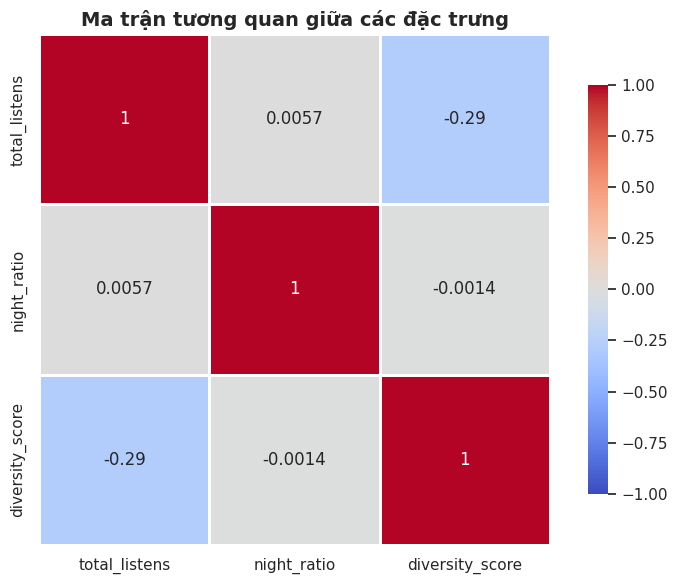

In [12]:
# --- Biểu đồ 3: Heatmap tương quan giữa các features ---
feature_corr = sample_data[['total_listens', 'night_ratio', 'diversity_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các đặc trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

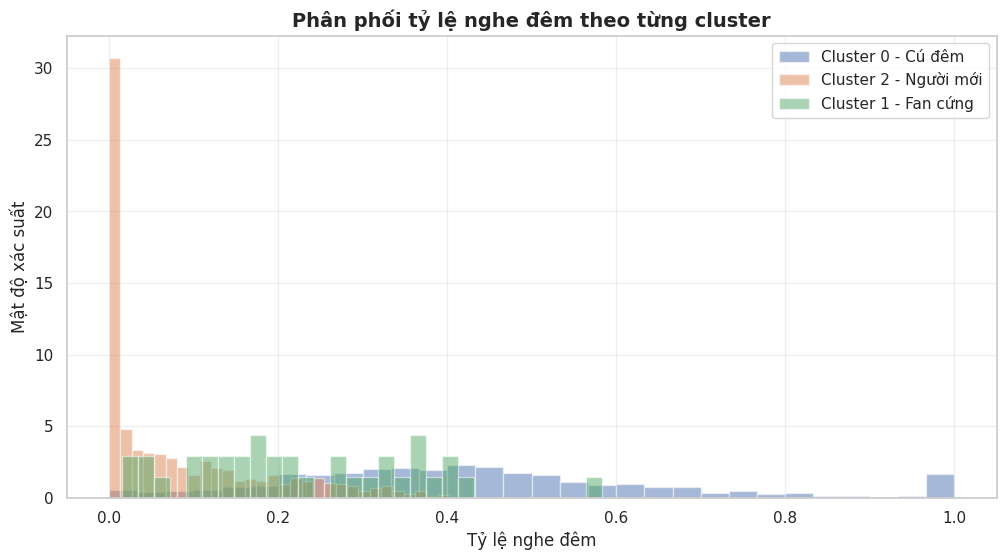

In [13]:
# --- Biểu đồ 4: Phân phối tỷ lệ nghe đêm theo cluster ---
plt.figure(figsize=(12, 6))
for cluster_id in sample_data['cluster'].unique():
    subset = sample_data[sample_data['cluster'] == cluster_id]
    user_type = label_mapping[cluster_id]
    plt.hist(subset['night_ratio'], bins=30, alpha=0.5, label=f'Cluster {cluster_id} - {user_type}', density=True)
plt.xlabel('Tỷ lệ nghe đêm', fontsize=12)
plt.ylabel('Mật độ xác suất', fontsize=12)
plt.title('Phân phối tỷ lệ nghe đêm theo từng cluster', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# 9. THỐNG KÊ KẾT QUẢ
# ==========================================
print("\n=== THỐNG KÊ KẾT QUẢ PHÂN LOẠI ===")
final_results.groupBy("user_type").agg(
    count("user_id").alias("số_lượng"),
    avg("total_listens").alias("lượt_nghe_TB"),
    avg("night_ratio").alias("tỷ_lệ_nghe_đêm_TB"),
    avg("diversity_score").alias("điểm_đa_dạng_TB")
).orderBy("user_type").show(truncate=False)

# Lưu kết quả
output_path = "/kaggle/working/user_classification_results"
final_results.select("user_id", "cluster", "user_type", "total_listens", "night_ratio", "diversity_score") \
    .write.mode("overwrite").option("header", "true").csv(output_path)

print(f"\nĐã lưu kết quả vào {output_path}")

# Dừng Spark session
spark.stop()


=== THỐNG KÊ KẾT QUẢ PHÂN LOẠI ===


+---------+--------+------------------+-------------------+------------------+
|user_type|số_lượng|lượt_nghe_TB      |tỷ_lệ_nghe_đêm_TB  |điểm_đa_dạng_TB   |
+---------+--------+------------------+-------------------+------------------+
|Cú đêm   |10064   |1945.015003974563 |0.43871771427473355|60.31708287230842 |
|Fan cứng |398     |137029.6783919598 |0.23320986605068417|21.636875708165082|
|Người mới|12914   |504.77141087192194|0.08002921731080041|80.52384475902696 |
+---------+--------+------------------+-------------------+------------------+




Đã lưu kết quả vào /kaggle/working/user_classification_results
